In [41]:
#FashionMNIST multi_input
#不变动位置

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import numpy as np

california_housing = fetch_california_housing(data_home='./data')
X, y = california_housing.data, california_housing.target

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

class CaliforniaHousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return (self.X[idx],self.X[idx][-2:]), self.y[idx].unsqueeze(0)

train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for (x1,x2),y in train_loader:
    print(x1.shape)
    print(x2.shape)
    print(y.shape)
    break

torch.Size([64, 8])
torch.Size([64, 2])
torch.Size([64, 1])


In [42]:
#WideDeep模型搭建
class WideDeep(nn.Module):
    def __init__(self, input_dim=(8,2)):
        super().__init__()
        self.deep = nn.Sequential(
            nn.Linear(input_dim[1], 30),
            nn.ReLU(),
            nn.Linear(30, 30),
            nn.ReLU()
        )
        
        self.out = nn.Linear(30 + input_dim[0], 1)
    
        self.init_weights()
    
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x_wide, x_deep):
        deep_out = self.deep(x_deep)
        concat = torch.cat([x_wide,deep_out], dim=1)
        return self.out(concat)



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = WideDeep(input_dim=(8,2))
model.to(device)

x_wide = torch.randn(4, 8).to(device)
x_deep = torch.randn(4, 2).to(device) 
output = model(x_wide, x_deep)

print(x_wide.shape)
print(x_deep.shape)
print(output.shape)
print(output)


cuda
torch.Size([4, 8])
torch.Size([4, 2])
torch.Size([4, 1])
tensor([[ 0.4119],
        [-0.2841],
        [ 0.1966],
        [ 0.1902]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [ ]:
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    loss_list = []
    for (datas_wide,datas_deep), labels in dataloader:
        datas_deep = datas_deep.to(device)
        datas_wide = datas_wide.to(device)
        labels = labels.to(device)
        logits = model(datas_wide, datas_deep)
        loss = loss_fct(logits, labels)
        loss_list.append(loss.item())
    return np.mean(loss_list)


In [44]:
from my_trainer import Trainer, EarlyStopping, ModelCheckpoint
from tqdm.auto import tqdm


# 初始化损失函数和优化器
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练
def training(model, train_loader, val_loader, epoch, loss_fct, optimizer, tensorboard_callback=None,save_ckpt_callback=None,early_stop_callback=None,eval_step=500,):
    record_dict = {
        "train": [],
        "val": []
    }
    
    global_step = 0
    model.train()
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            for (datas_wide,datas_deep), labels in train_loader:
                datas_deep = datas_deep.to(device)
                datas_wide = datas_wide.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                logits = model(datas_wide,datas_deep)
                loss = loss_fct(logits, labels)
                loss.backward()
                optimizer.step()
 
                loss = loss.cpu().item()
                record_dict["train"].append({
                    "loss": loss, "step": global_step
                })
                
                if global_step % eval_step == 0:
                    model.eval()
                    val_loss = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "step": global_step
                    })
                    model.train()
                
                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})
        
    return record_dict
        

epoch = 10



model = model.to(device)
record = training(model, train_loader, val_loader, epoch, criterion, optimizer,eval_step=len(train_loader))

  0%|          | 0/2260 [00:00<?, ?it/s]

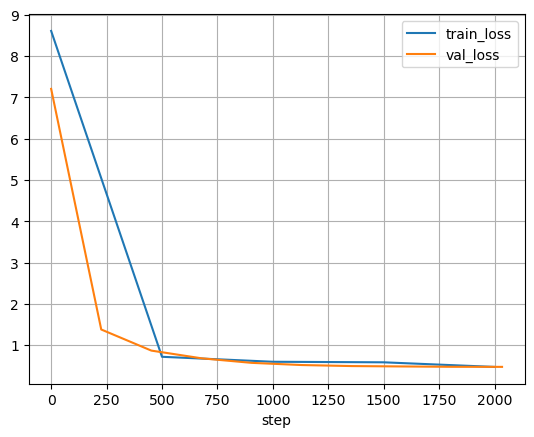

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_learn_curves(record_dict,sample_size=500):
    train_df = pd.DataFrame(record_dict['train']).set_index('step').iloc[::sample_size]
    val_df = pd.DataFrame(record_dict['val']).set_index('step')
    for idx ,item in enumerate(train_df.columns):
        plt.plot(train_df.index,train_df[item],label=f'train_{item}')
        plt.plot(val_df.index,val_df[item],label=f'val_{item}')
        plt.legend()
        plt.grid()
        plt.xlabel('step')
        plt.show()

plot_learn_curves(record, sample_size=500)